## Setup MSCOCO Val2017 Captions Dataset
We will use the MSCOCO Val2017 Captions dataset for evaluating vision-language misalignment and visual grounding.

In [5]:
# Install the required libraries
!pip install pillow matplotlib

In [6]:
import os
import urllib.request
import zipfile

# Check if dataset already exists
if not os.path.exists('./images/val2017'):
    print("Downloading COCO 2017 validation dataset...")
    
    # Create images directory if it doesn't exist
    os.makedirs('./images', exist_ok=True)
    
    # Download the validation dataset
    url = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = './images/val2017.zip'
    
    urllib.request.urlretrieve(url, zip_path)
    
    # Extract the zip file
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./images')
    
    # Remove the zip file
    os.remove(zip_path)
    print("Download complete!")
else:
    print("COCO 2017 validation dataset already exists in ./images directory")

COCO 2017 validation dataset already exists in ./images directory


In [7]:
# Download COCO 2017 captions for validation images
if not os.path.exists('./images/annotations'):
    print("Downloading COCO 2017 captions...")
    
    # Create annotations directory if it doesn't exist
    os.makedirs('./images/annotations', exist_ok=True)
    
    # Download the captions
    url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    zip_path = './images/annotations.zip'
    
    urllib.request.urlretrieve(url, zip_path)
    
    # Extract the zip file
    print("Extracting captions...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./images')
    
    # Remove the zip file
    os.remove(zip_path)
    print("Captions download complete!")
else:
    print("COCO 2017 captions already exist in ./images/annotations directory")

COCO 2017 captions already exist in ./images/annotations directory


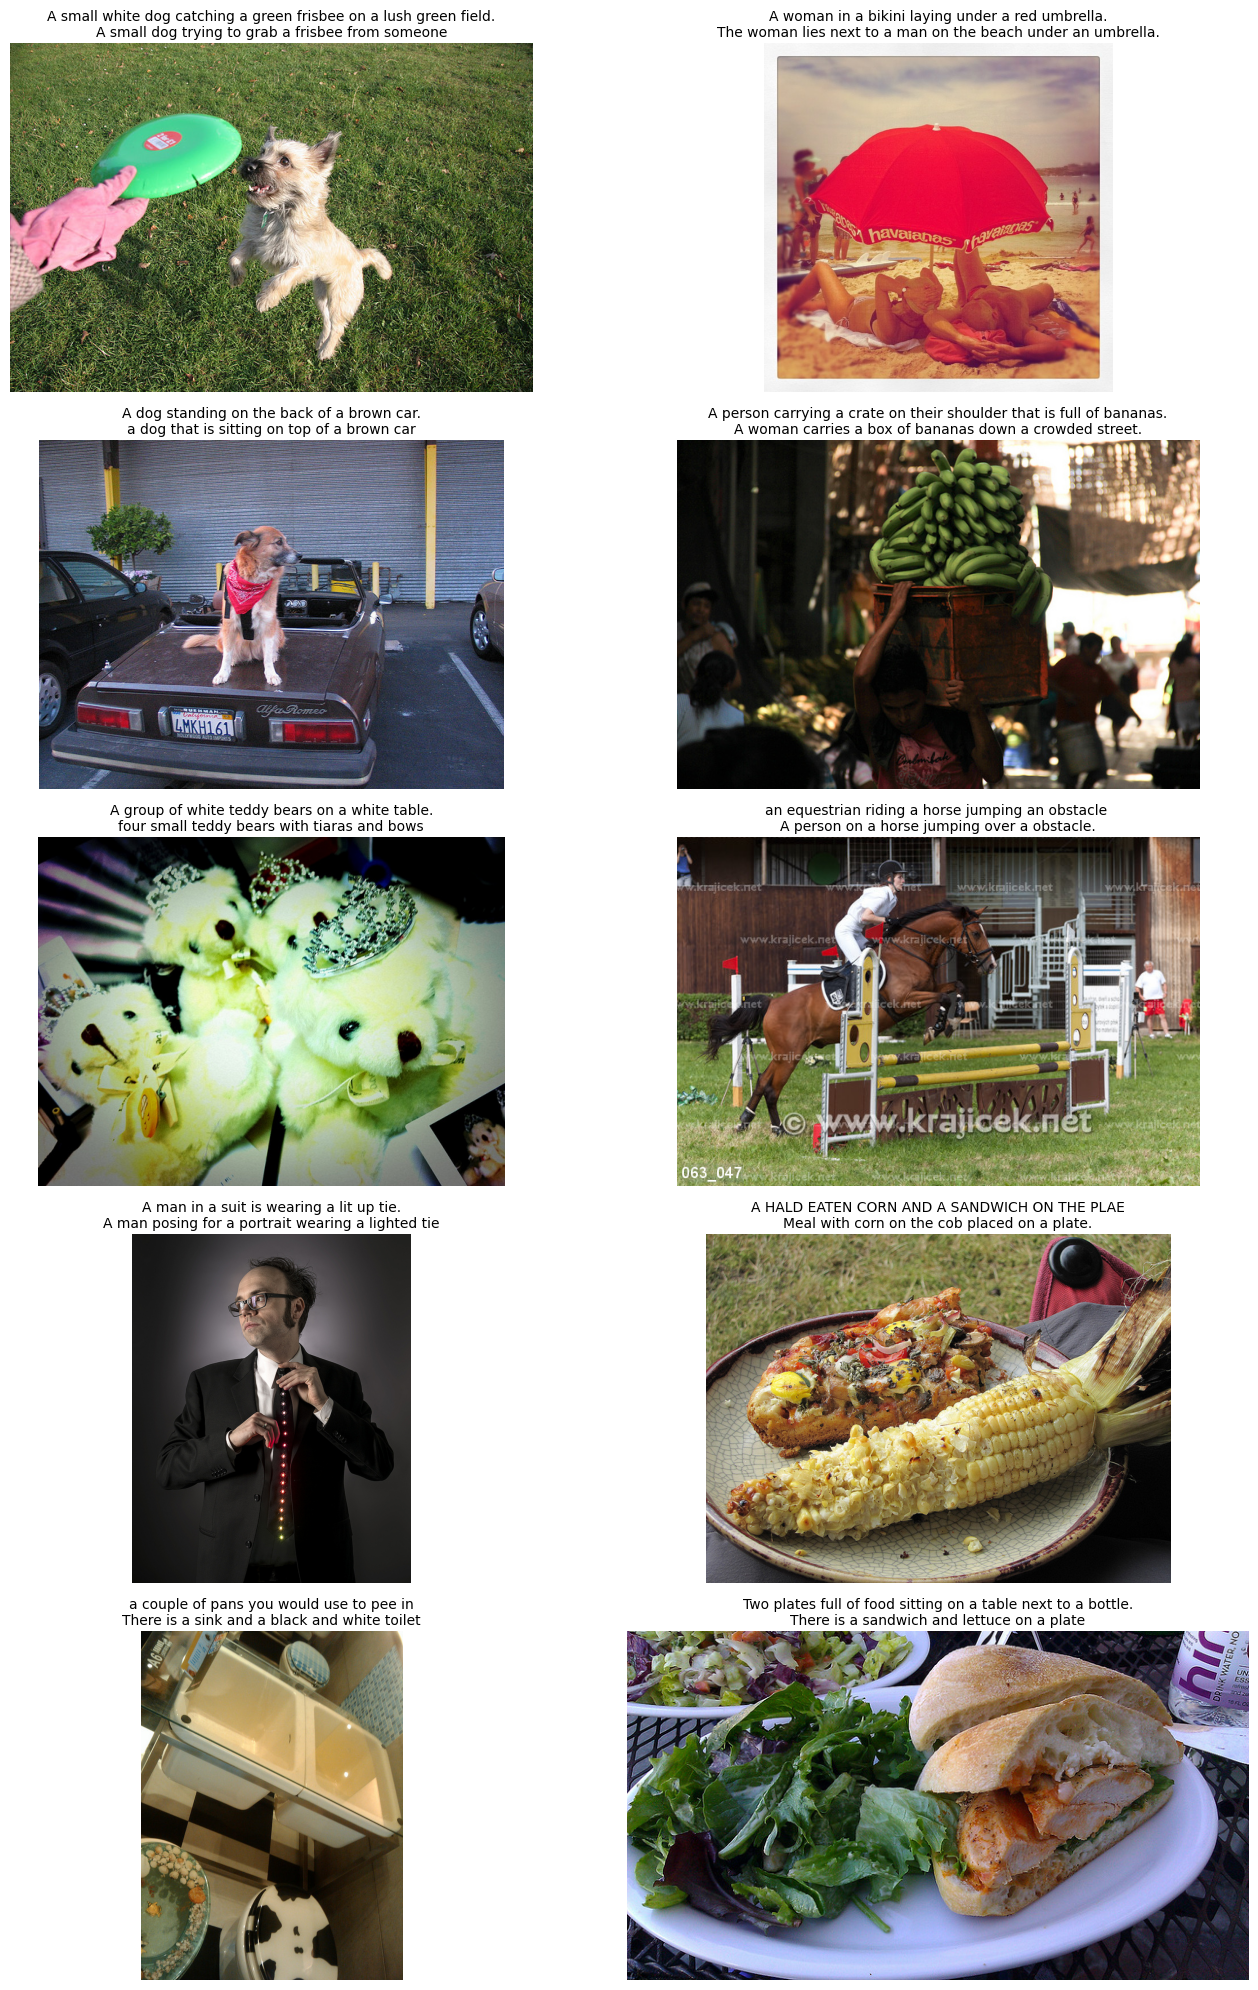

In [10]:
import json
import random
from PIL import Image
import matplotlib.pyplot as plt

# Load the COCO captions annotation file
coco_annotation_file = './images/annotations/captions_val2017.json'
with open(coco_annotation_file, 'r') as f:
    coco_data = json.load(f)

# Create a mapping of image_id to captions
image_captions = {}
for annotation in coco_data['annotations']:
    img_id = annotation['image_id']
    if img_id not in image_captions:
        image_captions[img_id] = []
    image_captions[img_id].append(annotation['caption'])

# Create a mapping of image_id to filename
id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}

# Display 10 images with their captions (choose randomly)
    
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, (img_id, filename) in enumerate(random.sample(list(id_to_filename.items()), 10)):
    img_path = f'./images/val2017/{filename}'
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    captions = image_captions.get(img_id, ['No caption'])
    axes[idx].set_title('\n'.join(captions[:2]), fontsize=10, wrap=True)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()